
# 05 Portfolio Monitoring ⭐⭐⭐⭐⭐

Enterprise-grade monitoring notebook for:
- portfolio risk segmentation
- calibration analysis
- threshold analysis
- false positive monitoring
- SHAP monitoring
- monotonicity validation
- feature drift governance


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings("ignore")


In [2]:

# LOAD ENGINEERED DATASET

application_train = pd.read_csv(
    "../data/processed/engineered_credit_risk_dataset.csv"
)

print(application_train.shape)

application_train.head()


(307511, 170)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,LAST_ACTIVE_DAYS_CREDIT,ACTIVE_EXTERNAL_DEBT,ACTIVE_DEBT_RATIO,MAX_INSTALLMENT,ANNUITY_TO_MAX_INSTALLMENT_RATIO,RECENT_DELAY_TREND,EXT_SOURCE_MEAN,EXT_SOURCE_STD,CREDIT_EXT_RATIO,THIN_FILE_CUSTOMER
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,-103.0,245781.0,0.999996,53093.745,0.465224,0.000000,0.161787,0.092026,2.511611e+06,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,-606.0,0.0,0.000000,560835.360,0.063652,0.000000,0.466757,0.219895,2.770664e+06,0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.000000,10573.965,0.638360,0.000000,0.642739,0.122792,2.100058e+05,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.000000,691786.890,0.042913,0.000000,0.650442,0.136021,4.806494e+05,0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.000000,22678.785,0.964139,-0.954545,0.322738,0.136021,1.589031e+06,0


In [3]:

# LOAD MODEL

xgb_model = joblib.load(
    "../models/final_credit_risk_xgboost_model.pkl"
)

print("Model loaded successfully.")


Model loaded successfully.


In [4]:

# FEATURE COLUMNS

feature_columns = [

    "ANNUITY_TO_INCOME",
    "CREDIT_TO_INCOME",
    "FREE_CASH_FLOW",
    "DEBT_TO_INCOME",
    "CREDIT_TO_ANNUITY_RATIO",
    "CREDIT_TO_GOODS_RATIO",
    "DOWN_PAYMENT",

    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_STD",
    "CREDIT_EXT_RATIO",

    "DEBT_PER_BUREAU_RECORD",
    "OVERDUE_PER_BUREAU_RECORD",
    "ACTIVE_DEBT_RATIO",
    "MEAN_DAYS_CREDIT",
    "LAST_ACTIVE_DAYS_CREDIT",

    "APPLICATIONS_PER_INCOME",
    "PREVIOUS_APPLICATION_COUNT",
    "RECENT_APPLICATION_COUNT",
    "BORROWING_ACCELERATION_RATIO",

    "LATE_PAYMENT_COUNT",
    "MISSED_PAYMENTS_PER_LOAN",
    "AVG_PAYMENT_DELAY",
    "AVG_PAYMENT_DEFICIT",
    "REPAYMENT_INSTABILITY",

    "LATE_PAYMENTS_LAST_90D",
    "AVG_PAYMENT_DELAY_LAST_90D",
    "RECENT_TO_HISTORICAL_DELAY_RATIO",
    "RECENT_DELAY_TREND",
    "RECENT_PAYMENT_DEFICIT",
    "PAYMENT_DEFICIT_TREND",
    "RECENT_PAYMENT_STABILITY",

    "YEARS_EMPLOYED",
    "EMPLOYMENT_TO_AGE_RATIO",
    "AGE_YEARS",

    "MAX_INSTALLMENT",
    "ANNUITY_TO_MAX_INSTALLMENT_RATIO",

    "BEHAVIORAL_RISK_SCORE"
]

X = application_train[feature_columns]

y = application_train["TARGET"]

print(X.shape)


(307511, 40)


In [5]:

# GENERATE PREDICTIONS

application_train["PD"] = (
    xgb_model.predict_proba(X)[:,1]
)

application_train[["TARGET", "PD"]].head()


,TARGET,PD
0,1,0.439965
1,0,0.080580
2,0,0.064061
3,0,0.073943
4,0,0.166013


In [6]:

# RISK SEGMENTATION

bins = [0, 0.10, 0.30, 0.60, 1.0]

labels = [
    "LOW",
    "MEDIUM",
    "HIGH",
    "VERY_HIGH"
]

application_train["RISK_SEGMENT"] = pd.cut(
    application_train["PD"],
    bins=bins,
    labels=labels
)

application_train["RISK_SEGMENT"].value_counts()


RISK_SEGMENT
LOW          161396
MEDIUM       107816
HIGH          33184
VERY_HIGH      5115
Name: count, dtype: int64

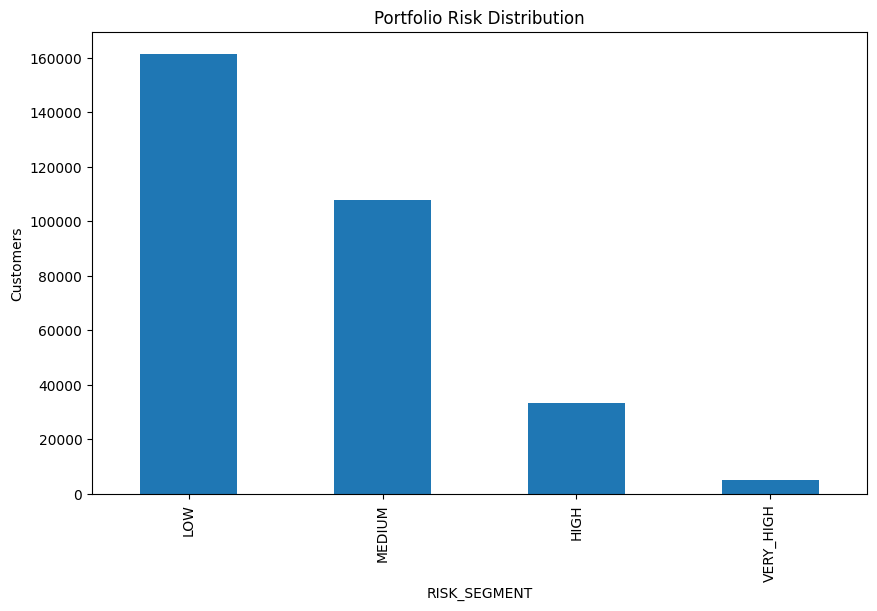

In [7]:

# PORTFOLIO DISTRIBUTION

segment_counts = (
    application_train["RISK_SEGMENT"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,6))

segment_counts.plot(kind="bar")

plt.title("Portfolio Risk Distribution")

plt.ylabel("Customers")

plt.show()


RISK_SEGMENT
LOW          0.024809
MEDIUM       0.096600
HIGH         0.242888
VERY_HIGH    0.458651
Name: TARGET, dtype: float64

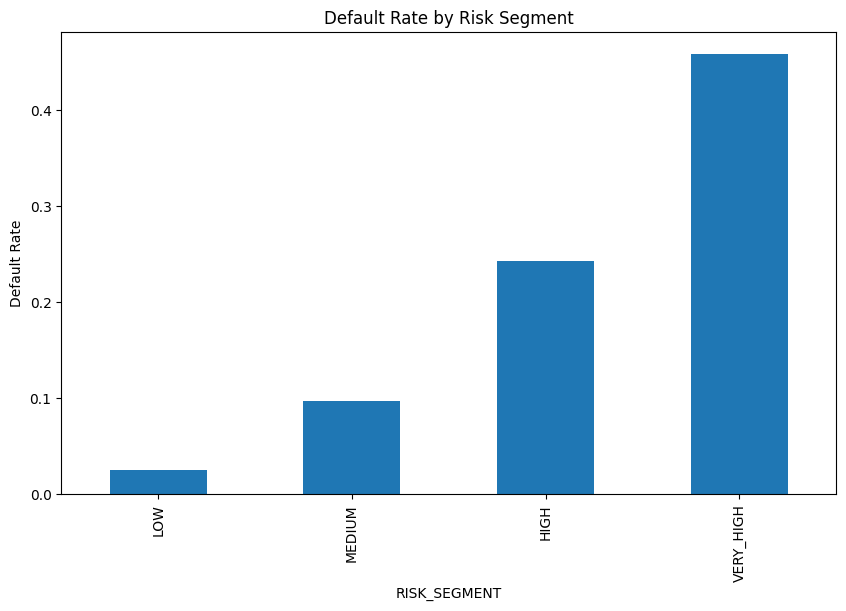

In [8]:

# DEFAULT RATE PER SEGMENT

segment_default_rate = (
    application_train
    .groupby("RISK_SEGMENT")["TARGET"]
    .mean()
)

display(segment_default_rate)

plt.figure(figsize=(10,6))

segment_default_rate.plot(kind="bar")

plt.title("Default Rate by Risk Segment")

plt.ylabel("Default Rate")

plt.show()


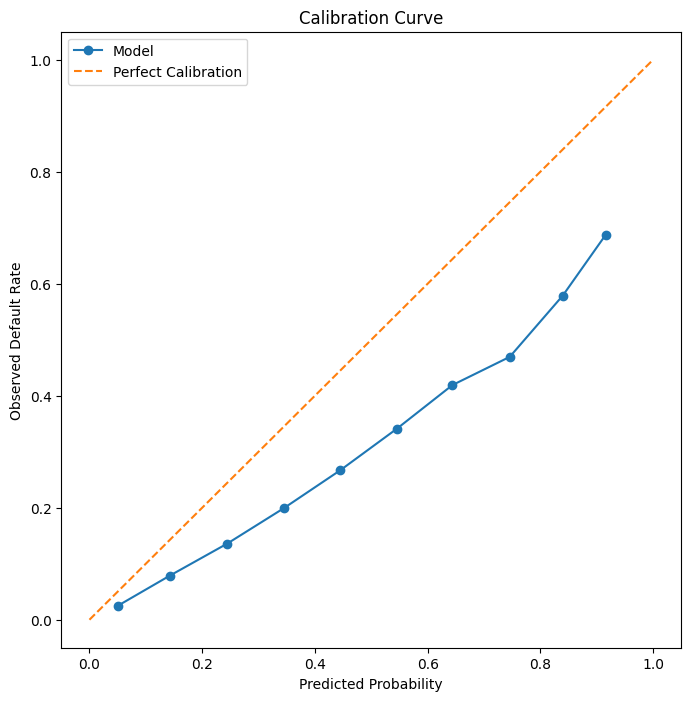

In [9]:

# CALIBRATION ANALYSIS

prob_true, prob_pred = calibration_curve(
    y,
    application_train["PD"],
    n_bins=10
)

plt.figure(figsize=(8,8))

plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    label='Model'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Perfect Calibration'
)

plt.xlabel("Predicted Probability")

plt.ylabel("Observed Default Rate")

plt.title("Calibration Curve")

plt.legend()

plt.show()


In [10]:

# THRESHOLD ANALYSIS

thresholds = np.arange(0.1, 1.0, 0.05)

results = []

for threshold in thresholds:

    preds = (
        application_train["PD"] > threshold
    ).astype(int)

    precision = precision_score(
        y,
        preds,
        zero_division=0
    )

    recall = recall_score(
        y,
        preds
    )

    f1 = f1_score(
        y,
        preds
    )

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

display(threshold_df.head())


,Threshold,Precision,Recall,F1
0,0.10,0.142497,0.838711,0.243606
1,0.15,0.175799,0.715448,0.282245
2,0.20,0.208104,0.603706,0.309514
3,0.25,0.240108,0.505982,0.325672
4,0.30,0.271704,0.419174,0.329700


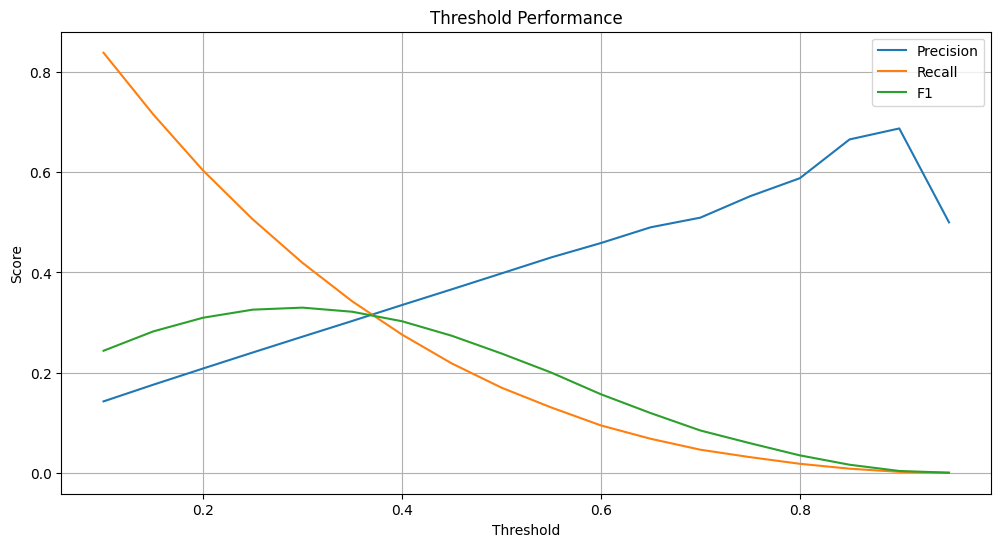

In [11]:

# THRESHOLD VISUALIZATION

plt.figure(figsize=(12,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.title("Threshold Performance")

plt.legend()

plt.grid()

plt.show()


[[281586   1100]
 [ 23683   1142]]


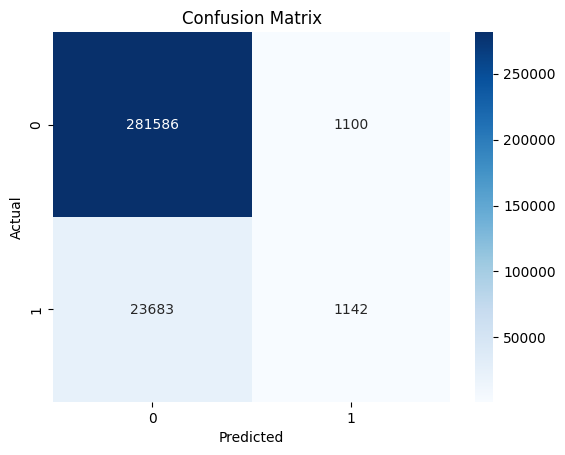

In [13]:

# CONFUSION MATRIX

threshold = 0.70

preds = (
    application_train["PD"] > threshold
).astype(int)

cm = confusion_matrix(y, preds)

print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


In [14]:

# MODEL PERFORMANCE SUMMARY

print(
    classification_report(
        y,
        preds
    )
)

print(
    f"ROC AUC: "
    f"{roc_auc_score(y, application_train['PD']):.4f}"
)


              precision    recall  f1-score   support

           0       0.92      1.00      0.96    282686
           1       0.51      0.05      0.08     24825

    accuracy                           0.92    307511
   macro avg       0.72      0.52      0.52    307511
weighted avg       0.89      0.92      0.89    307511

ROC AUC: 0.7844


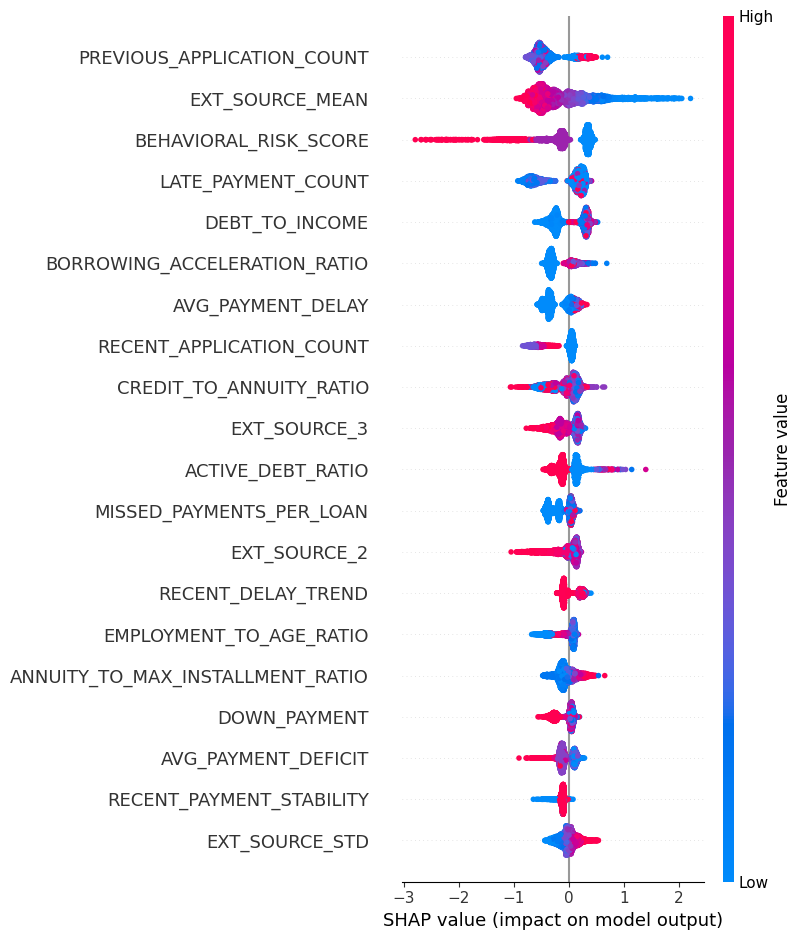

In [15]:

# SHAP GLOBAL MONITORING

explainer = shap.TreeExplainer(
    xgb_model
)

sample_X = X.sample(
    5000,
    random_state=42
)

shap_values = explainer.shap_values(
    sample_X
)

shap.summary_plot(
    shap_values,
    sample_X,
    max_display=20
)


DTI_BIN
(-15.516, 0.0]       0.072717
(0.0, 0.00385]       0.067187
(0.00385, 0.606]     0.077266
(0.606, 1.441]       0.078794
(1.441, 2.666]       0.085848
(2.666, 4.617]       0.088976
(4.617, 8.315]       0.092420
(8.315, 1651.844]    0.093233
Name: TARGET, dtype: float64

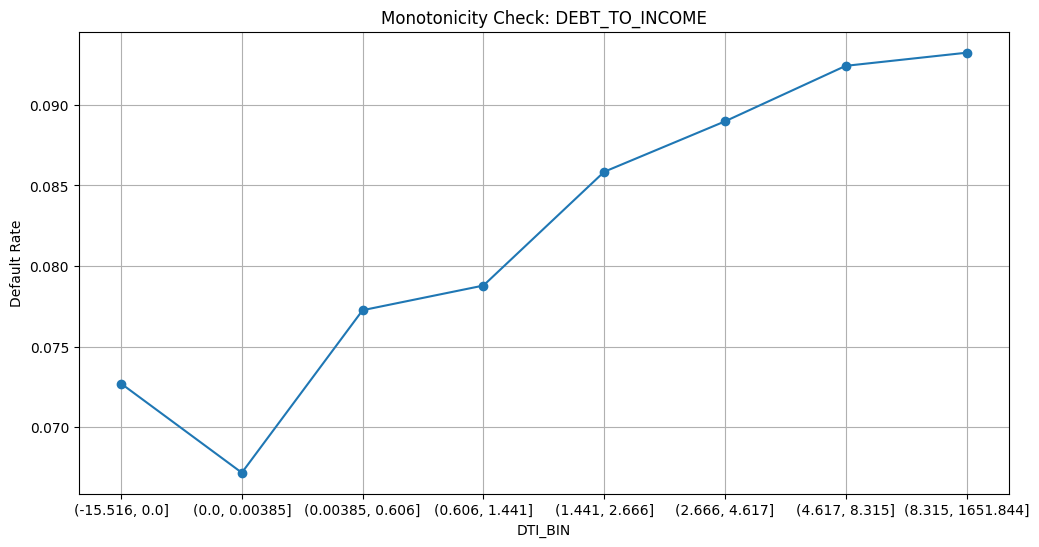

In [16]:

# MONOTONICITY CHECK

feature_to_check = "DEBT_TO_INCOME"

application_train["DTI_BIN"] = pd.qcut(
    application_train[feature_to_check],
    10,
    duplicates="drop"
)

monotonicity_check = (
    application_train
    .groupby("DTI_BIN")["TARGET"]
    .mean()
)

display(monotonicity_check)

plt.figure(figsize=(12,6))

monotonicity_check.plot(marker='o')

plt.title(
    f"Monotonicity Check: {feature_to_check}"
)

plt.ylabel("Default Rate")

plt.grid()

plt.show()


In [17]:

# HIGH-RISK CUSTOMER AUDIT

high_risk_customers = application_train[

    application_train["PD"] > 0.70

].copy()

high_risk_customers = high_risk_customers[[
    "TARGET",
    "PD",
    "RISK_SEGMENT",
    "DEBT_TO_INCOME",
    "LATE_PAYMENT_COUNT",
    "RECENT_DELAY_TREND",
    "BEHAVIORAL_RISK_SCORE"
]]

display(
    high_risk_customers.head(20)
)


,TARGET,PD,RISK_SEGMENT,DEBT_TO_INCOME,LATE_PAYMENT_COUNT,RECENT_DELAY_TREND,BEHAVIORAL_RISK_SCORE
16,0,0.751832,VERY_HIGH,1.139708,0.0,0.000000,1
41,0,0.716093,VERY_HIGH,0.000000,1.0,0.660448,0
128,0,0.871242,VERY_HIGH,0.425474,2.0,1.571429,0
160,0,0.767328,VERY_HIGH,0.000000,4.0,2.894737,0
211,1,0.718631,VERY_HIGH,1.206967,0.0,0.000000,1
235,1,0.739129,VERY_HIGH,0.000000,20.0,1.005309,1
471,1,0.885102,VERY_HIGH,0.948650,0.0,0.000000,0
563,1,0.718065,VERY_HIGH,0.000000,5.0,-4.666667,0
603,1,0.751712,VERY_HIGH,0.000000,3.0,-3.375000,0
695,0,0.828726,VERY_HIGH,9.142914,3.0,0.275000,1


In [18]:
## ananlyse not clear FPs

# EXTRACT FULL FEATURE ROWS ⭐⭐⭐⭐⭐



interesting_cases = application_train.loc[

    [1332, 1465, 1476]

][
    [

        "TARGET",
        "PD",

        # AFFORDABILITY
        "DEBT_TO_INCOME",
        "FREE_CASH_FLOW",
        "CREDIT_TO_INCOME",
        "ANNUITY_TO_INCOME",

        # EXTERNAL
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3",
        "EXT_SOURCE_MEAN",
        "EXT_SOURCE_STD",

        # BUREAU
        "ACTIVE_DEBT_RATIO",
        "DEBT_PER_BUREAU_RECORD",
        "OVERDUE_PER_BUREAU_RECORD",
        "MEAN_DAYS_CREDIT",

        # REPAYMENT
        "LATE_PAYMENT_COUNT",
        "AVG_PAYMENT_DELAY",
        "AVG_PAYMENT_DEFICIT",
        "REPAYMENT_INSTABILITY",

        # TEMPORAL
        "RECENT_DELAY_TREND",
        "RECENT_PAYMENT_DEFICIT",
        "RECENT_TO_HISTORICAL_DELAY_RATIO",

        # APPLICATION
        "PREVIOUS_APPLICATION_COUNT",
        "RECENT_APPLICATION_COUNT",
        "BORROWING_ACCELERATION_RATIO",

        # EMPLOYMENT
        "YEARS_EMPLOYED",
        "EMPLOYMENT_TO_AGE_RATIO",
        "AGE_YEARS",

        # COMPOSITE
        "BEHAVIORAL_RISK_SCORE",

        # THIN FILE
        "THIN_FILE_CUSTOMER"
    ]
]

display(interesting_cases.T)

,1332,1465,1476
TARGET,1.000000,1.000000,0.000000
PD,0.787382,0.722097,0.714167
DEBT_TO_INCOME,0.000000,0.000000,0.000000
FREE_CASH_FLOW,94131.000000,105079.500000,144067.500000
CREDIT_TO_INCOME,3.706880,3.316800,2.074057
ANNUITY_TO_INCOME,0.163280,0.221633,0.085286
EXT_SOURCE_1,0.505998,0.505998,0.505998
EXT_SOURCE_2,0.069296,0.078749,0.057216
EXT_SOURCE_3,0.535276,0.535276,0.535276
EXT_SOURCE_MEAN,0.069296,0.078749,0.057216


,Feature,Importance,importance_pct
20,RECENT_APPLICATION_COUNT,0.128182,0.128182
22,LATE_PAYMENT_COUNT,0.093078,0.093078
33,RECENT_PAYMENT_STABILITY,0.093027,0.093027
10,EXT_SOURCE_MEAN,0.077884,0.077884
26,REPAYMENT_INSTABILITY,0.070125,0.070125
19,PREVIOUS_APPLICATION_COUNT,0.048233,0.048233
24,AVG_PAYMENT_DELAY,0.044067,0.044067
27,LATE_PAYMENTS_LAST_90D,0.038184,0.038184
21,BORROWING_ACCELERATION_RATIO,0.037240,0.037240
39,BEHAVIORAL_RISK_SCORE,0.035350,0.035350


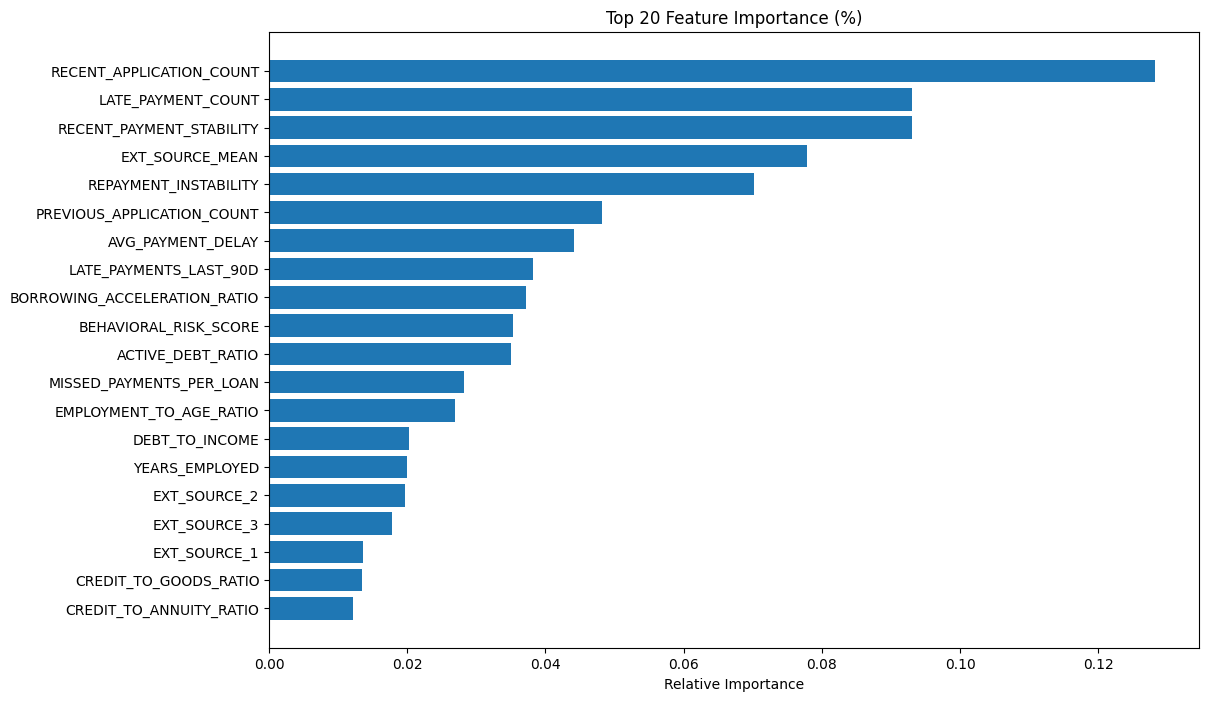

In [20]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# EXTRACT IMPORTANCE
# ------------------------------------------------------------

importance_df = pd.DataFrame({

    "Feature": feature_columns,

    "Importance": xgb_model.feature_importances_
})

# ------------------------------------------------------------
# SORT FEATURES
# ------------------------------------------------------------

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False
)

# ------------------------------------------------------------
# IMPORTANCE PERCENTAGE ⭐⭐⭐
# ------------------------------------------------------------

importance_df["importance_pct"] = (

    importance_df["Importance"]

    /

    importance_df["Importance"].sum()
)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

display(

    importance_df.head(20)
)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(12,8))

plt.barh(

    importance_df["Feature"][:20],

    importance_df["importance_pct"][:20]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 20 Feature Importance (%)"
)

plt.xlabel(
    "Relative Importance"
)

plt.show()

NameError: name 'importance_df' is not defined

In [21]:
import shap

# ============================================================
# SHAP SAMPLE
# ============================================================

sample_X = X.sample(

    5000,

    random_state=42
)

# ============================================================
# SHAP EXPLAINER
# ============================================================

explainer = shap.TreeExplainer(
    xgb_model
)

# ============================================================
# SHAP VALUES
# ============================================================

shap_values = explainer.shap_values(
    sample_X
)

print("SHAP values generated.")

SHAP values generated.


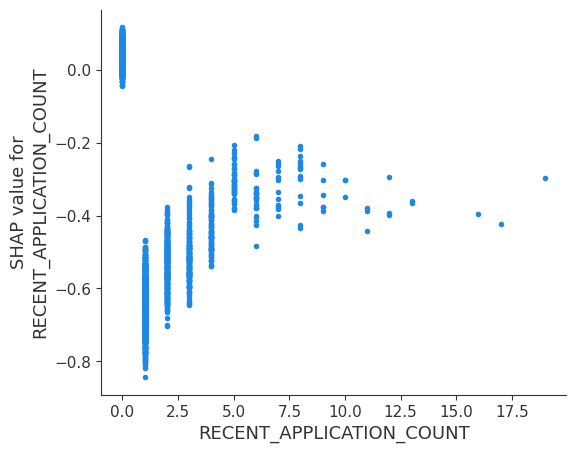

In [22]:
shap.dependence_plot(

    "RECENT_APPLICATION_COUNT",

    shap_values,

    sample_X,

    interaction_index=None
)

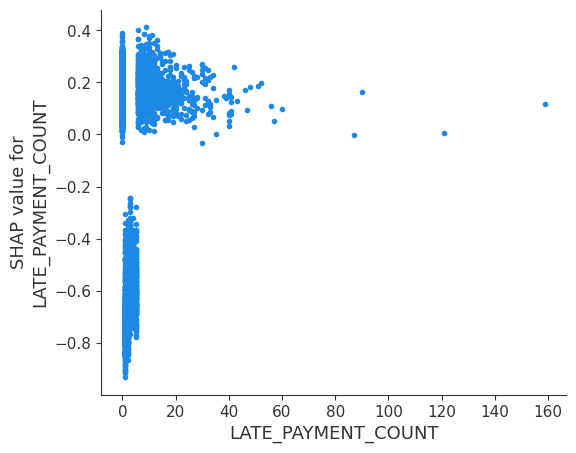

In [23]:
shap.dependence_plot(

    "LATE_PAYMENT_COUNT",

    shap_values,

    sample_X,

    interaction_index=None
)

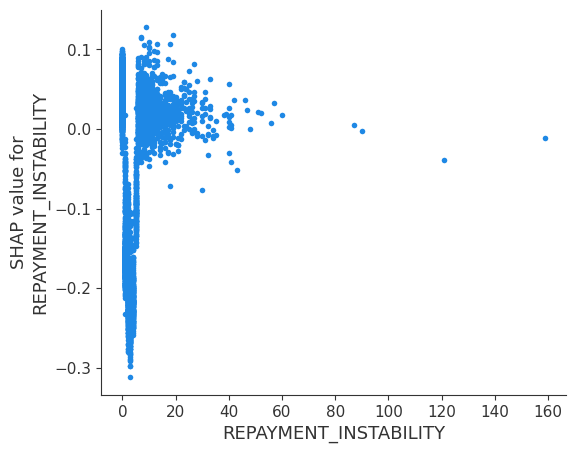

In [24]:
shap.dependence_plot(

    "REPAYMENT_INSTABILITY",

    shap_values,

    sample_X,

    interaction_index=None
)

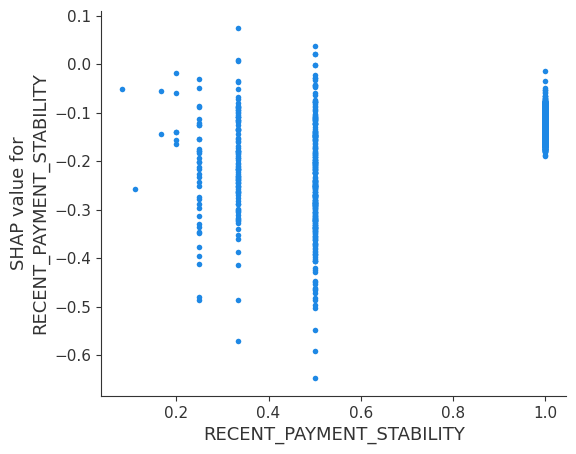

In [25]:
shap.dependence_plot(

    "RECENT_PAYMENT_STABILITY",

    shap_values,

    sample_X,

    interaction_index=None
)

In [26]:
application_train[
    "RECENT_APPLICATION_COUNT"
].describe()

count    307511.000000
mean          0.622592
std           1.429778
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          46.000000
Name: RECENT_APPLICATION_COUNT, dtype: float64

In [27]:
application_train.groupby(
    "RECENT_APPLICATION_COUNT"
)["TARGET"].mean()

RECENT_APPLICATION_COUNT
0.0     0.077456
1.0     0.082623
2.0     0.091916
3.0     0.095504
4.0     0.093549
5.0     0.101274
6.0     0.109515
7.0     0.094140
8.0     0.107937
9.0     0.103753
10.0    0.099265
11.0    0.135678
12.0    0.097403
13.0    0.114943
14.0    0.067797
15.0    0.179487
16.0    0.121212
17.0    0.031250
18.0    0.090909
19.0    0.117647
20.0    0.111111
21.0    0.250000
22.0    0.285714
23.0    0.000000
24.0    0.600000
25.0    0.000000
26.0    0.333333
28.0    0.000000
29.0    0.000000
30.0    0.333333
31.0    0.250000
32.0    0.500000
34.0    0.000000
35.0    1.000000
36.0    0.000000
41.0    0.000000
44.0    0.000000
46.0    0.000000
Name: TARGET, dtype: float64

In [28]:
application_train.groupby(
    "RECENT_APPLICATION_COUNT"
)["TARGET"].agg(
    ["count", "mean"]
)

,count,mean
RECENT_APPLICATION_COUNT,,
0.0,217929,0.077456
1.0,46343,0.082623
2.0,20671,0.091916
3.0,9675,0.095504
4.0,5131,0.093549
5.0,2982,0.101274
6.0,1671,0.109515
7.0,1041,0.094140
8.0,630,0.107937


In [29]:
application_train[
    "RECENT_APPLICATION_COUNT_CAPPED"
] = np.clip(

    application_train[
        "RECENT_APPLICATION_COUNT"
    ],

    0,

    10
)